<a href="https://colab.research.google.com/github/lilianabs/hugging-face-review/blob/main/Text_classification_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load a dataset using Hugging Face

In [2]:
from huggingface_hub import HfApi

# Initialize the API client
api = HfApi()

# Fetch all datasets
datasets = api.list_datasets()

# Print the first 10 dataset IDs as an example
for i, dataset in enumerate(datasets):
    if i >= 10:
        break
    print(dataset.id)

HuggingFaceFW/fineweb
HuggingFaceH4/ultrachat_200k
Anthropic/hh-rlhf
rajpurkar/squad
stanfordnlp/imdb
openai/gsm8k
tatsu-lab/alpaca
databricks/databricks-dolly-15k
r0b0tlab/qwen3.8-max-glm5.2-kimi-k3-distillation
HuggingFaceCode/stack-v3-train


In [3]:
from datasets import load_dataset
emotions = load_dataset('dair-ai/emotion')


README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [4]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [5]:
train_ds = emotions['train']
train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [6]:
# Access a single example by its index
train_ds[0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [7]:
print(train_ds.features)

{'text': Value('string'), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])}


In [8]:
import pandas as pd

In [9]:
emotions.set_format(type="pandas")

In [10]:
df = emotions["train"][:]
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [11]:
# Add full label names
def label_int2str(row):
  return emotions["train"].features["label"].int2str(row)

df["label_name"] = df["label"].apply(label_int2str)
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


## EDA

In [12]:
import matplotlib.pyplot as plt


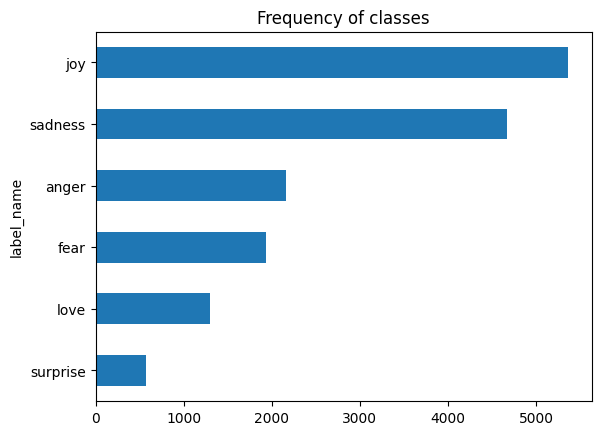

In [13]:
df["label_name"].value_counts(ascending=True).plot.barh()
plt.title("Frequency of classes")
plt.show()

Text(0.5, 0, '')

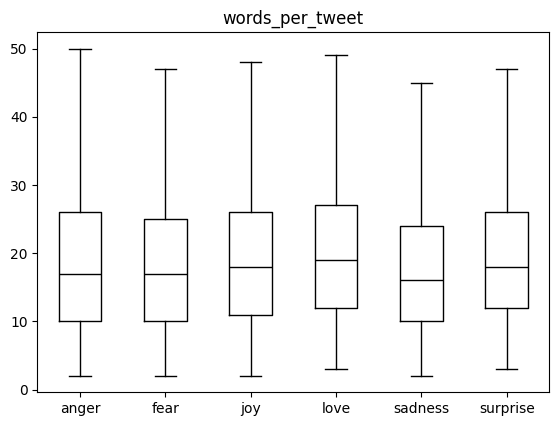

In [14]:
df["words_per_tweet"] = df["text"].str.split().apply(len)
df.boxplot("words_per_tweet", by="label_name",
           grid=False, color="black", showfliers=False);
plt.suptitle("")
plt.xlabel("")

In [15]:
df.head()

,text,label,label_name,words_per_tweet
0,i didnt feel humiliated,0,sadness,4
1,i can go from feeling so hopeless to so damned...,0,sadness,21
2,im grabbing a minute to post i feel greedy wrong,3,anger,10
3,i am ever feeling nostalgic about the fireplac...,2,love,18
4,i am feeling grouchy,3,anger,4


## Tokenizing text

In [16]:
from transformers import AutoTokenizer

In [17]:
model_ckpt = "distilbert/distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [18]:
text = "Tokenizing text is a core task of NLP."

In [19]:
encoded_text = tokenizer(text)
print(encoded_text)

{'input_ids': [101, 19204, 6026, 3793, 2003, 1037, 4563, 4708, 1997, 17953, 2361, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [20]:
tokens = tokenizer.convert_ids_to_tokens(encoded_text.input_ids)
print(tokens)

['[CLS]', 'token', '##izing', 'text', 'is', 'a', 'core', 'task', 'of', 'nl', '##p', '.', '[SEP]']


In [21]:
print(tokenizer.convert_tokens_to_string(tokens))

[CLS] tokenizing text is a core task of nlp. [SEP]


In [22]:
tokenizer.vocab_size

30522

In [23]:
# Model's maximum context size
tokenizer.model_max_length

512

### Tokenizing the whole dataset

In [24]:
def tokenize(batch):
  return tokenizer(batch["text"], padding=True, truncationg=True)

In [25]:
# Check the special tokens
tokens2ids = list(zip(tokenizer.all_special_tokens, tokenizer.all_special_ids))
data = sorted(tokens2ids, key=lambda x : x[-1])
df = pd.DataFrame(data, columns=["Special Token", "Special Token ID"])
df.T

,0,1,2,3,4
Special Token,[PAD],[UNK],[CLS],[SEP],[MASK]
Special Token ID,0,100,101,102,103


In [26]:
def tokenize(batch):
  # Ensure batch["text"] is a list of strings for the tokenizer
  return tokenizer(list(batch["text"]), padding=True, truncation=True)

emotions_encoded = emotions.map(tokenize, batched=True, batch_size=None)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

## Train a text classifier

In [38]:
import torch
from transformers import AutoTokenizer, AutoModel

# 1. Load the architecture-agnostic tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased")

# Define device and move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

text = "Extracting the last hidden state from DistilBERT using Auto classes."

# 2. Tokenize input text into PyTorch tensors
inputs = tokenizer(text, return_tensors="pt")
# Move input tensors to the same device as the model
inputs = {k: v.to(device) for k, v in inputs.items()}

# 3. Disable gradient calculation for inference
with torch.no_grad():
    outputs = model(**inputs)

# 4. Extract the last hidden state
# Shape: [batch_size, sequence_length, hidden_size]
last_hidden_state = outputs.last_hidden_state

print("Shape:", last_hidden_state.shape)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Shape: torch.Size([1, 16, 768])


In [33]:
emotions_encoded

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def extract_hidden_states(batch):
    # Place model inputs on the GPU
    inputs = {k:v.to(device) for k,v in batch.items()
              if k in tokenizer.model_input_names}
    # Extract last hidden states
    with torch.no_grad():
        last_hidden_state = model(**inputs).last_hidden_state
    # Return vector for [CLS] token
    return {"hidden_state": last_hidden_state[:,0].cpu().numpy()}

In [34]:
# Before setting format, add the 'label' column back to emotions_encoded
# This is necessary because the tokenize function did not carry over the 'label'
for split in emotions_encoded.keys():
    if 'label' not in emotions_encoded[split].features:
        # Assuming that 'emotions' dataset still holds the original 'label' column
        emotions_encoded[split] = emotions_encoded[split].add_column("label", emotions[split]['label'])

emotions_encoded.set_format("torch",
                            columns=["input_ids", "token_type_ids", "attention_mask", "label"])

In [39]:
emotions_encoded.reset_format() # Reset format to avoid the torchvision.io import error

# Redefine extract_hidden_states to handle tensor conversion manually
# Use the 'device' variable already defined globally (from cell I21fpUNpuWEf)
def extract_hidden_states(batch):
    inputs = {}
    for k, v in batch.items():
        if k in tokenizer.model_input_names:
            # Explicitly convert to PyTorch tensor if not already one
            if not isinstance(v, torch.Tensor):
                # If it's a list or numpy array, convert it to a tensor
                if isinstance(v, list) or isinstance(v, np.ndarray):
                    v = torch.tensor(v)
                # If it's a pandas Series (less likely after reset_format, but for robustness)
                elif isinstance(v, pd.Series):
                    v = torch.tensor(v.tolist())
            inputs[k] = v.to(device)

    # Extract last hidden states
    with torch.no_grad():
        last_hidden_state = model(**inputs).last_hidden_state
    # Return vector for [CLS] token
    return {"hidden_state": last_hidden_state[:,0].cpu().numpy()}

emotions_hidden = emotions_encoded.map(extract_hidden_states, batched=True)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [40]:
# Create a feature matrix

import numpy as np

X_train = np.array(emotions_hidden["train"]["hidden_state"])
X_valid = np.array(emotions_hidden["validation"]["hidden_state"])
y_train = np.array(emotions_hidden["train"]["label"])
y_valid = np.array(emotions_hidden["validation"]["label"])
X_train.shape, X_valid.shape

((16000, 768), (2000, 768))

In [41]:

from umap import UMAP
from sklearn.preprocessing import MinMaxScaler

# Scale features to [0,1] range
X_scaled = MinMaxScaler().fit_transform(X_train)
# Initialize and fit UMAP
mapper = UMAP(n_components=2, metric="cosine").fit(X_scaled)
# Create a DataFrame of 2D embeddings
df_emb = pd.DataFrame(mapper.embedding_, columns=["X", "Y"])
df_emb["label"] = y_train
df_emb.head()

,X,Y,label
0,4.290268,3.226536,0
1,-2.925991,3.777814,0
2,4.973473,6.717965,3
3,-2.603313,6.040084,2
4,-3.403116,5.581923,3


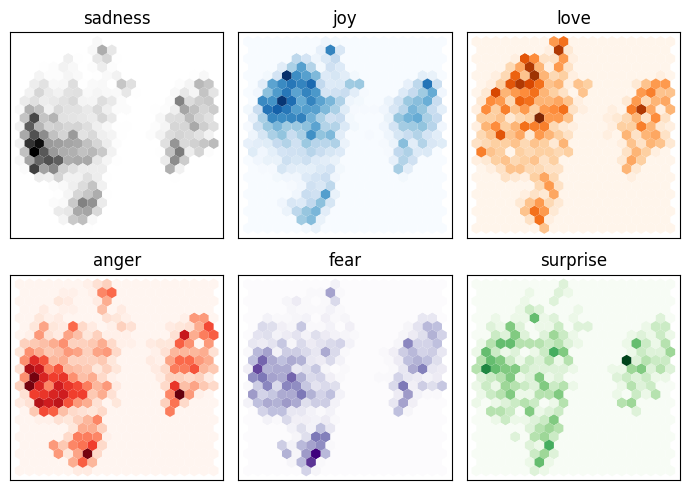

In [42]:

fig, axes = plt.subplots(2, 3, figsize=(7,5))
axes = axes.flatten()
cmaps = ["Greys", "Blues", "Oranges", "Reds", "Purples", "Greens"]
labels = emotions["train"].features["label"].names

for i, (label, cmap) in enumerate(zip(labels, cmaps)):
    df_emb_sub = df_emb.query(f"label == {i}")
    axes[i].hexbin(df_emb_sub["X"], df_emb_sub["Y"], cmap=cmap,
                   gridsize=20, linewidths=(0,))
    axes[i].set_title(label)
    axes[i].set_xticks([]), axes[i].set_yticks([])

plt.tight_layout()
plt.show()

## Training a simple classifier

In [43]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(max_iter=3000)
lr_clf.fit(X_train, y_train)

LogisticRegression(max_iter=3000)

In [44]:
lr_clf.score(X_valid, y_valid)

0.634

In [45]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
dummy_clf.score(X_valid, y_valid)

0.352

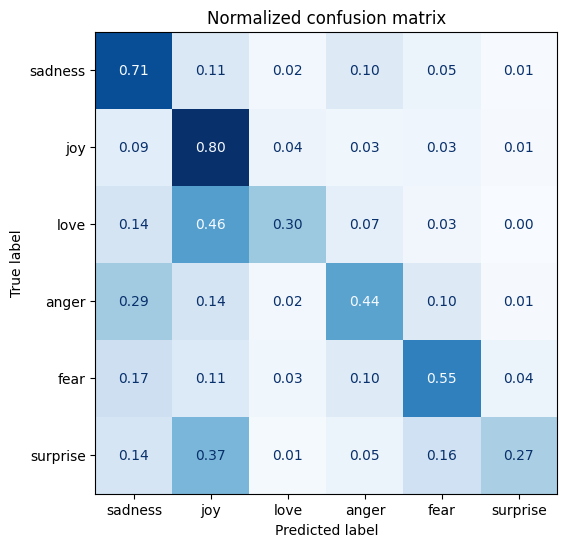

In [46]:

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def plot_confusion_matrix(y_preds, y_true, labels):
    cm = confusion_matrix(y_true, y_preds, normalize="true")
    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format=".2f", ax=ax, colorbar=False)
    plt.title("Normalized confusion matrix")
    plt.show()

y_preds = lr_clf.predict(X_valid)
plot_confusion_matrix(y_preds, y_valid, labels)
